# Stock Market Trend Analysis

## Project Introduction 

In [ ]:
This project focuses on predicting stock price trends—Downtrend, Sideways, and Uptrend
using technical indicators derived from historical market data. The objective is to apply machine learning techniques
to financial time-series data and evaluate their ability to identify meaningful patterns in a highly noisy and volatile market environment.
Four historical datasets were provided for this analysis:
1. company_info.csv – Contains company-level information, including the company’s full name, stock ticker symbol, sector classification, and initial public offering (IPO) date.
2.market_indices.csv – Provides market-wide indicators that reflect overall market conditions such as currency strength and general stock market performance.
3.stock_prices.csv – Includes daily stock price data in OHLCV format (Open, High, Low, Close, and Volume).
4.stock_prices_with_indicators.csv – Extends price and volume data with engineered technical indicators, including RSI, MACD, Bollinger Bands, volatility measures, and momentum-based features.

The primary goal of this project is to build machine learning models that can improve trend prediction performance compared to a simple baseline model, 
despite the inherent noise and uncertainty present in financial markets.
The project was structured into two phases. Phase 1 focused on model development and evaluation.
During Phase 1 (Week 1), the foundation for the Stock Market Trend Analysis project was established 
through an in-depth understanding of financial time-series data and comprehensive exploratory data analysis (EDA). 
Phase 1 (Week 2) involved building baseline machine learning models for trend prediction, evaluating 
their performance, and developing more advanced models using Random Forest and feature importance techniques. 
This phase resulted in a multi-class classification model with documented performance metrics and interpretability insights.
Phase 2 was designed to transition the trained models from Phase 1 into production-ready
systems using professional MLOps practices. This phase aimed to include model versioning, performance validation
through backtesting, API deployment for real-time predictions, and the development of an interactive dashboard for stakeholders.
However, Phase 2 was later suspended as it was considered beyond the scope appropriate for a beginner-level project.








E. Final Insights & Recommendations

Financial markets are highly noisy, so modest accuracy is expected.

Technical indicators lag price movements, making turning points difficult to predict.

The Random Forest model performs better than the baseline by capturing non-linear patterns.

Next steps include:

Hyperparameter tuning

Trying XGBoost or Gradient Boosting

Backtesting trading strategies

Applying rolling-window validation and MLOps practices


## Key Exploratory Data Analysis (EDA) Insights

The following visuals were used to understand market behavior and indicator dynamics:

In [4]:
from IPython.display import Image, display

### . Price Trend Example
Shows strong volatility and frequent trend changes, highlighting market noise.

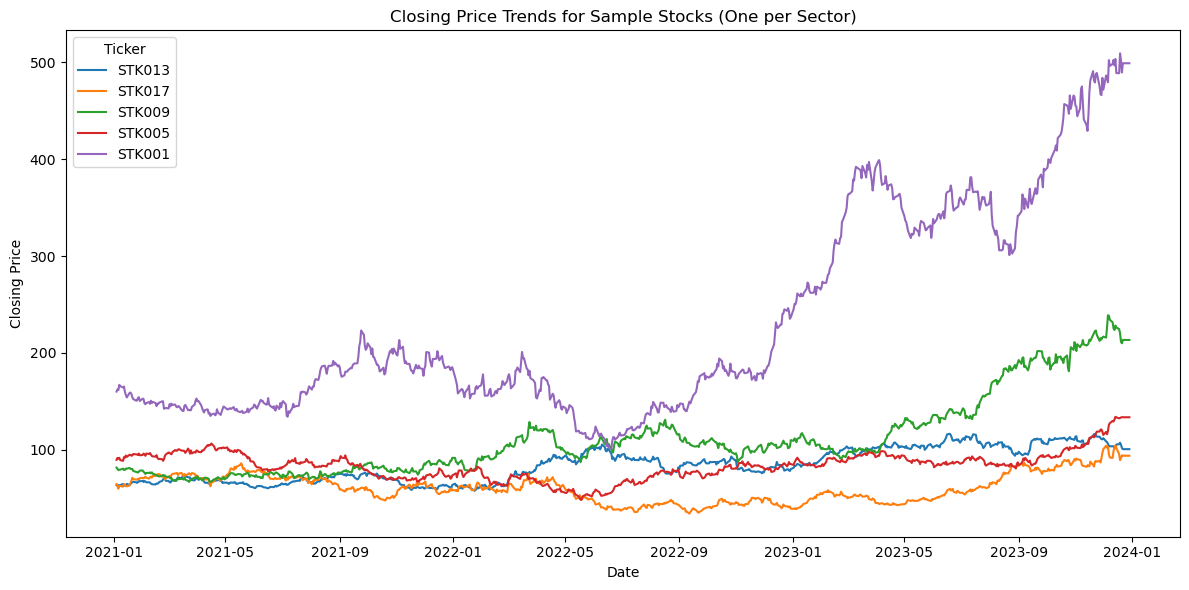

In [10]:
display(Image('../visuals/eda/closing_price_trends.png'))

### 2. RSI Indicator Example
Demonstrates overbought and oversold regions, but with delayed reactions to price changes.


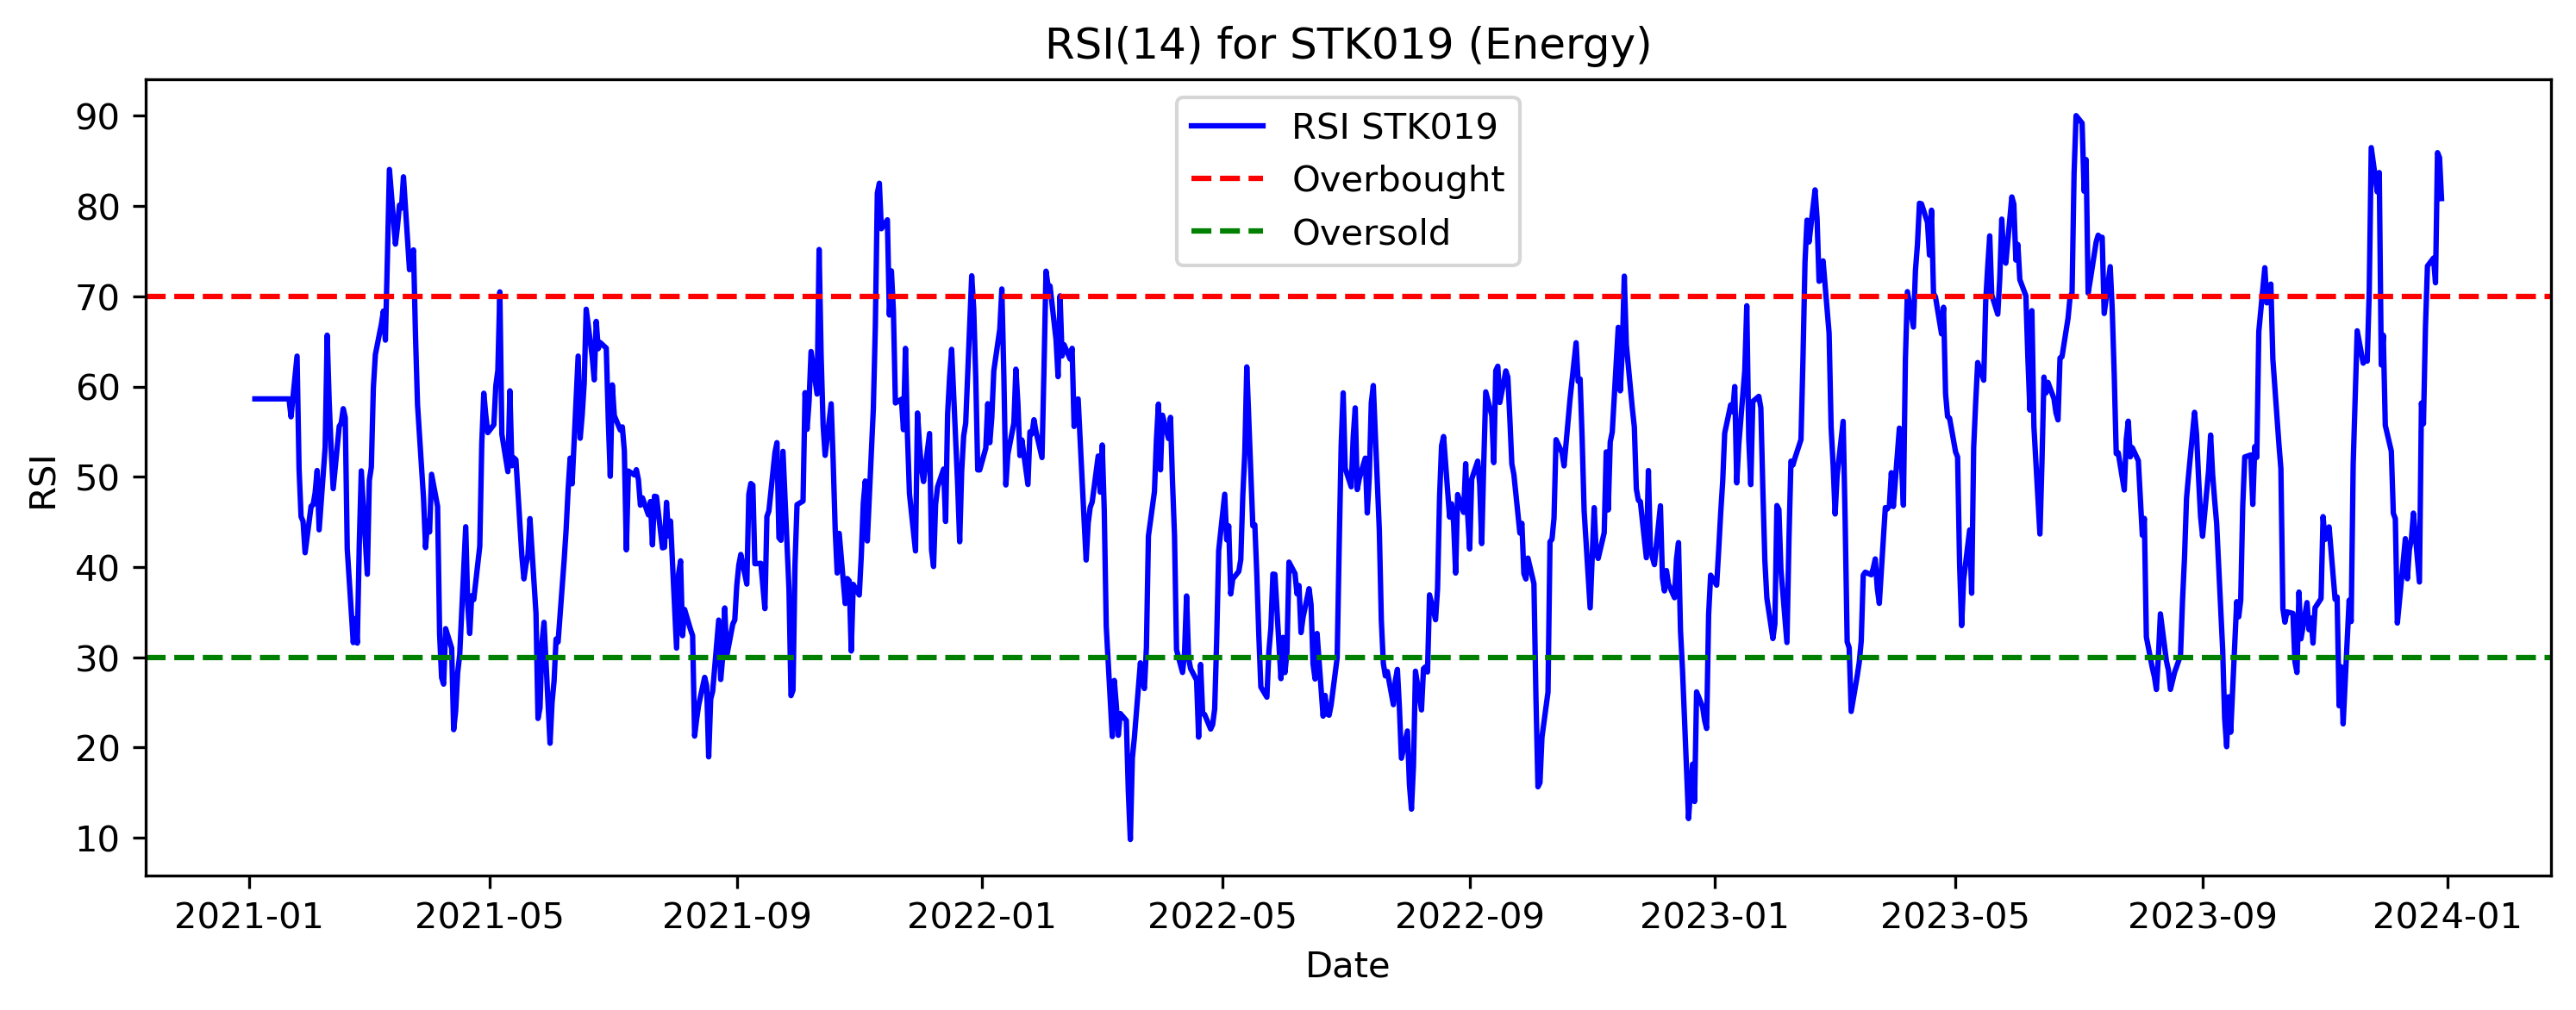

In [12]:
display(Image('../visuals/eda/rsi(14)_for_selected_ticker.png'))

The RSI(14) plot for the selected stock shows several peaks above 70, indicating overbought conditions followed by short-term price corrections. Occasional dips below 30 suggest oversold periods where the stock may have been undervalued before rebounding. Overall, the RSI pattern highlights alternating phases of buying and selling pressure, consistent with cyclical market behavior.

### 3. MACD Crossover Example
Captures momentum shifts; crossovers often occur after price movements.


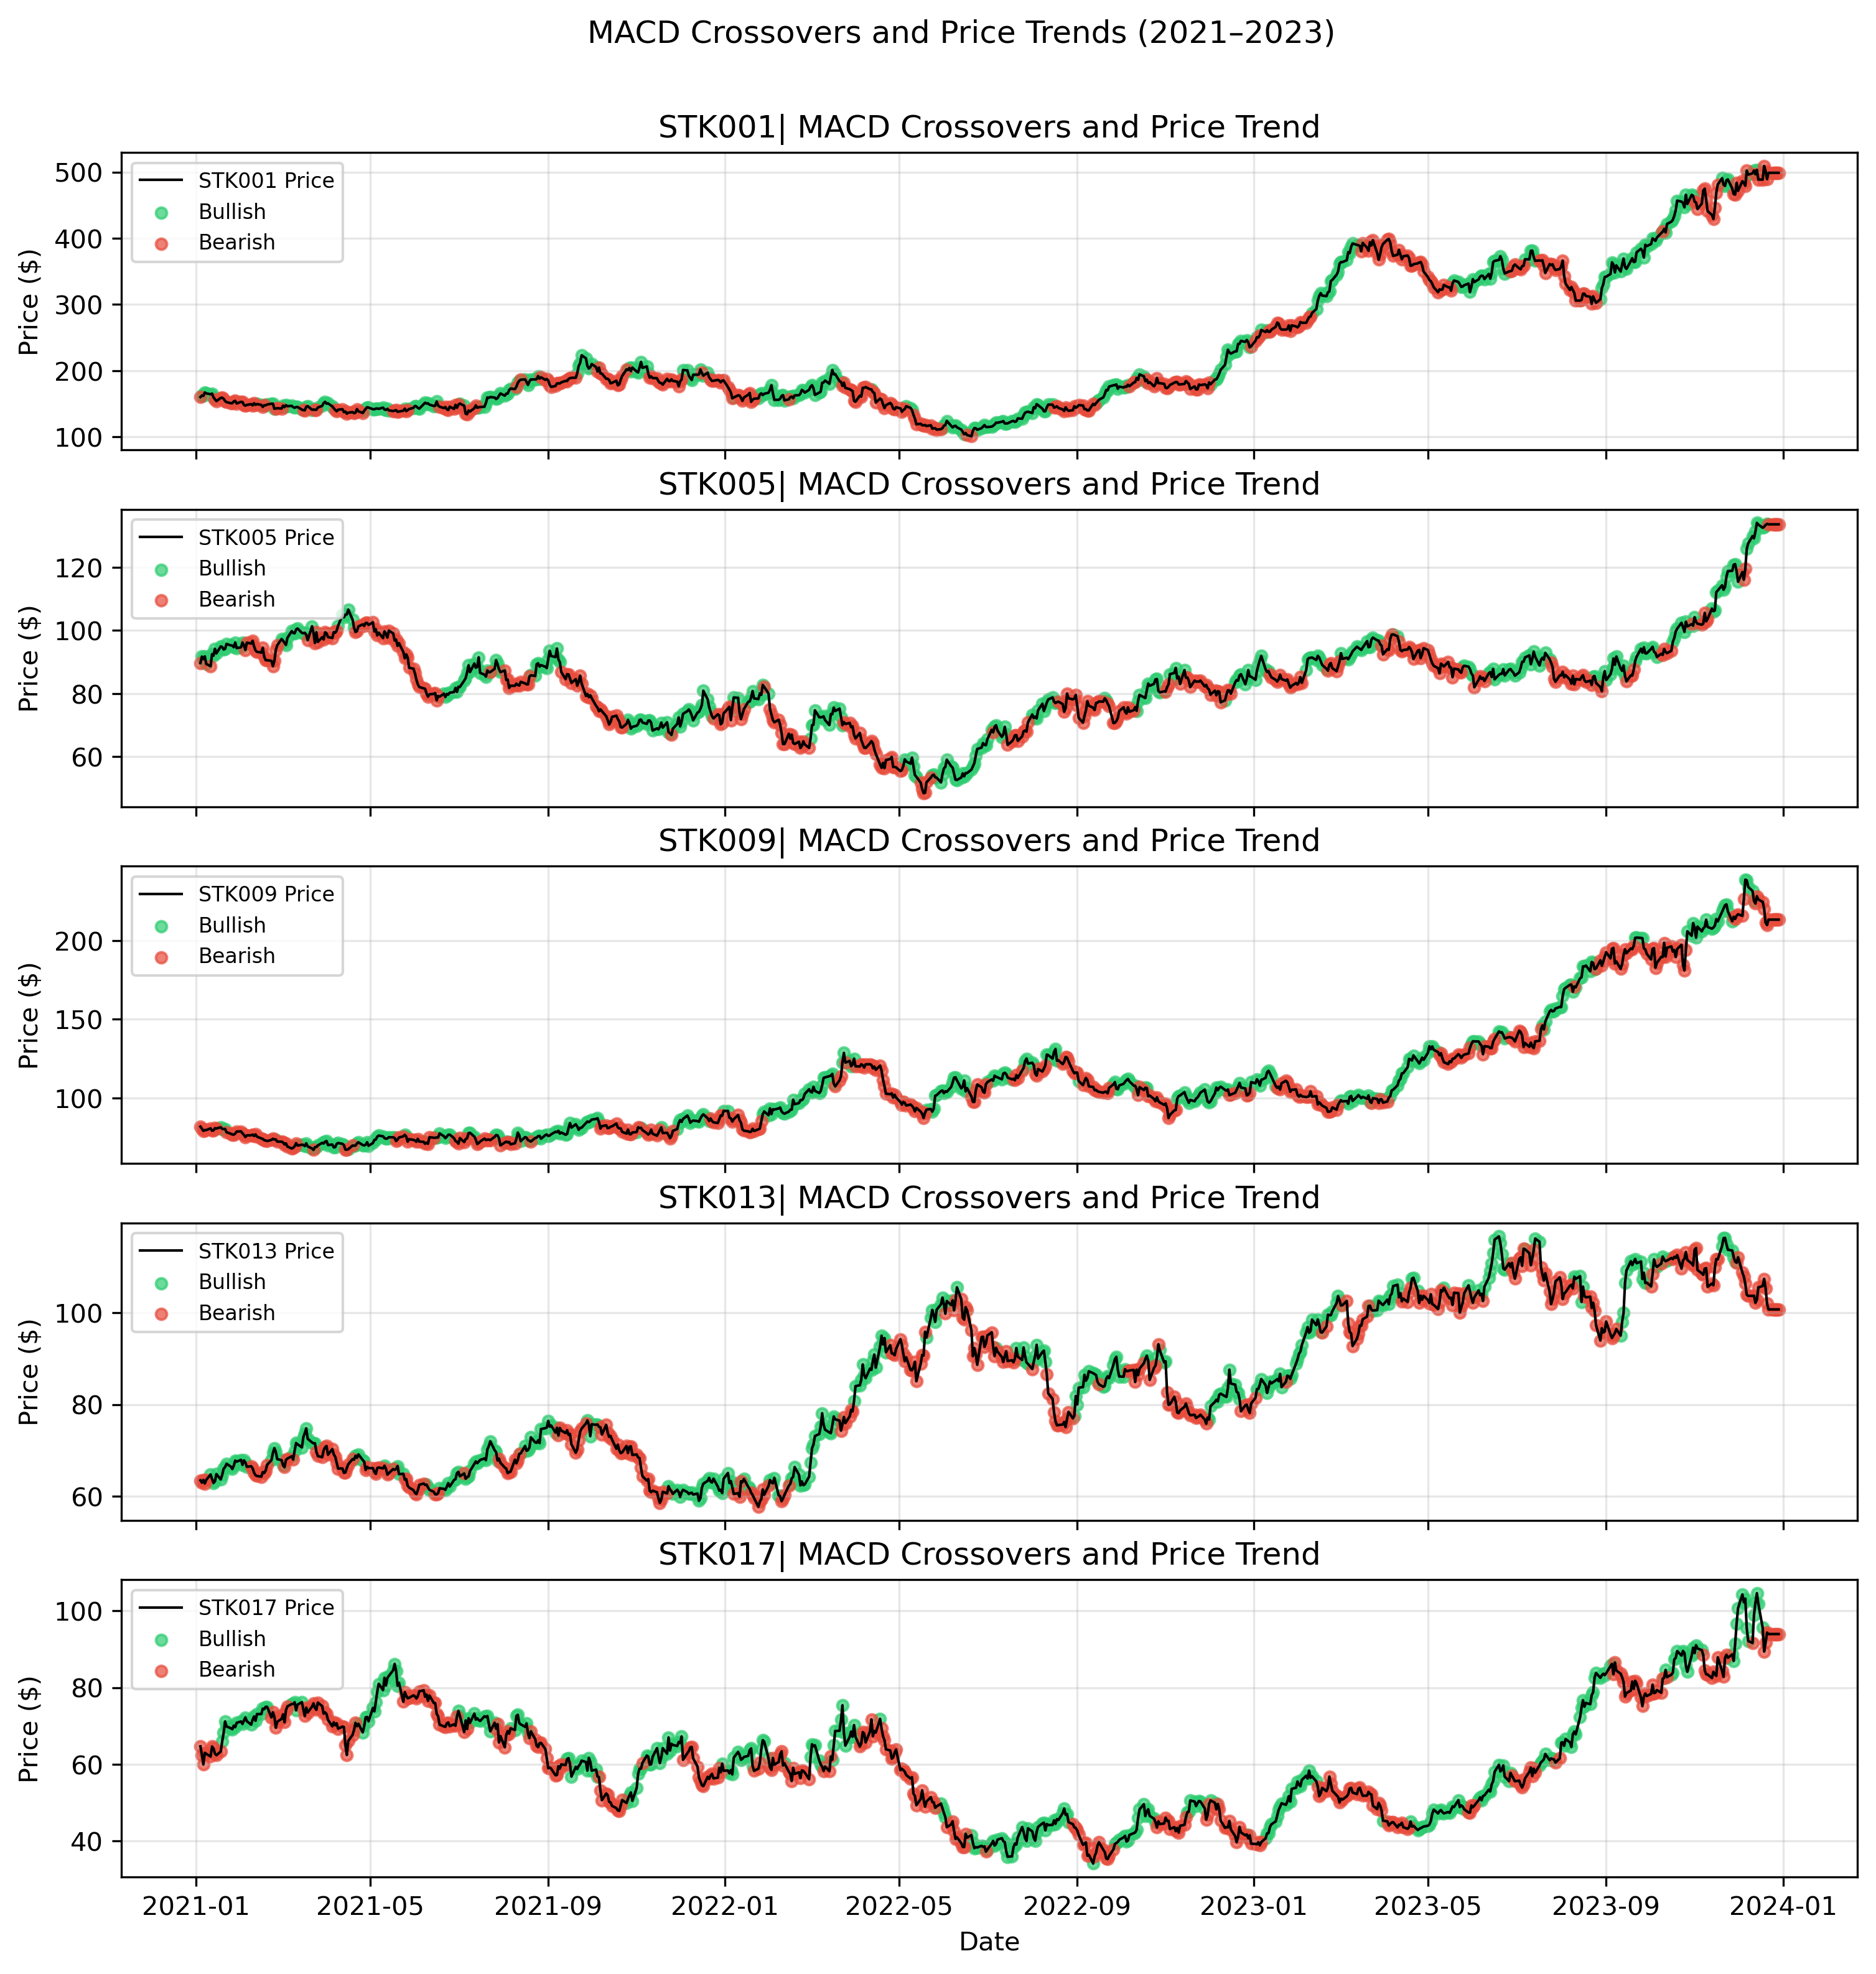

In [13]:
display(Image('../visuals/eda/macd_crossovers_price_trend.png'))

### 4. Bollinger Bands / Sector Volatility
Indicates periods of high and low volatility, helping explain uncertainty in predictions.


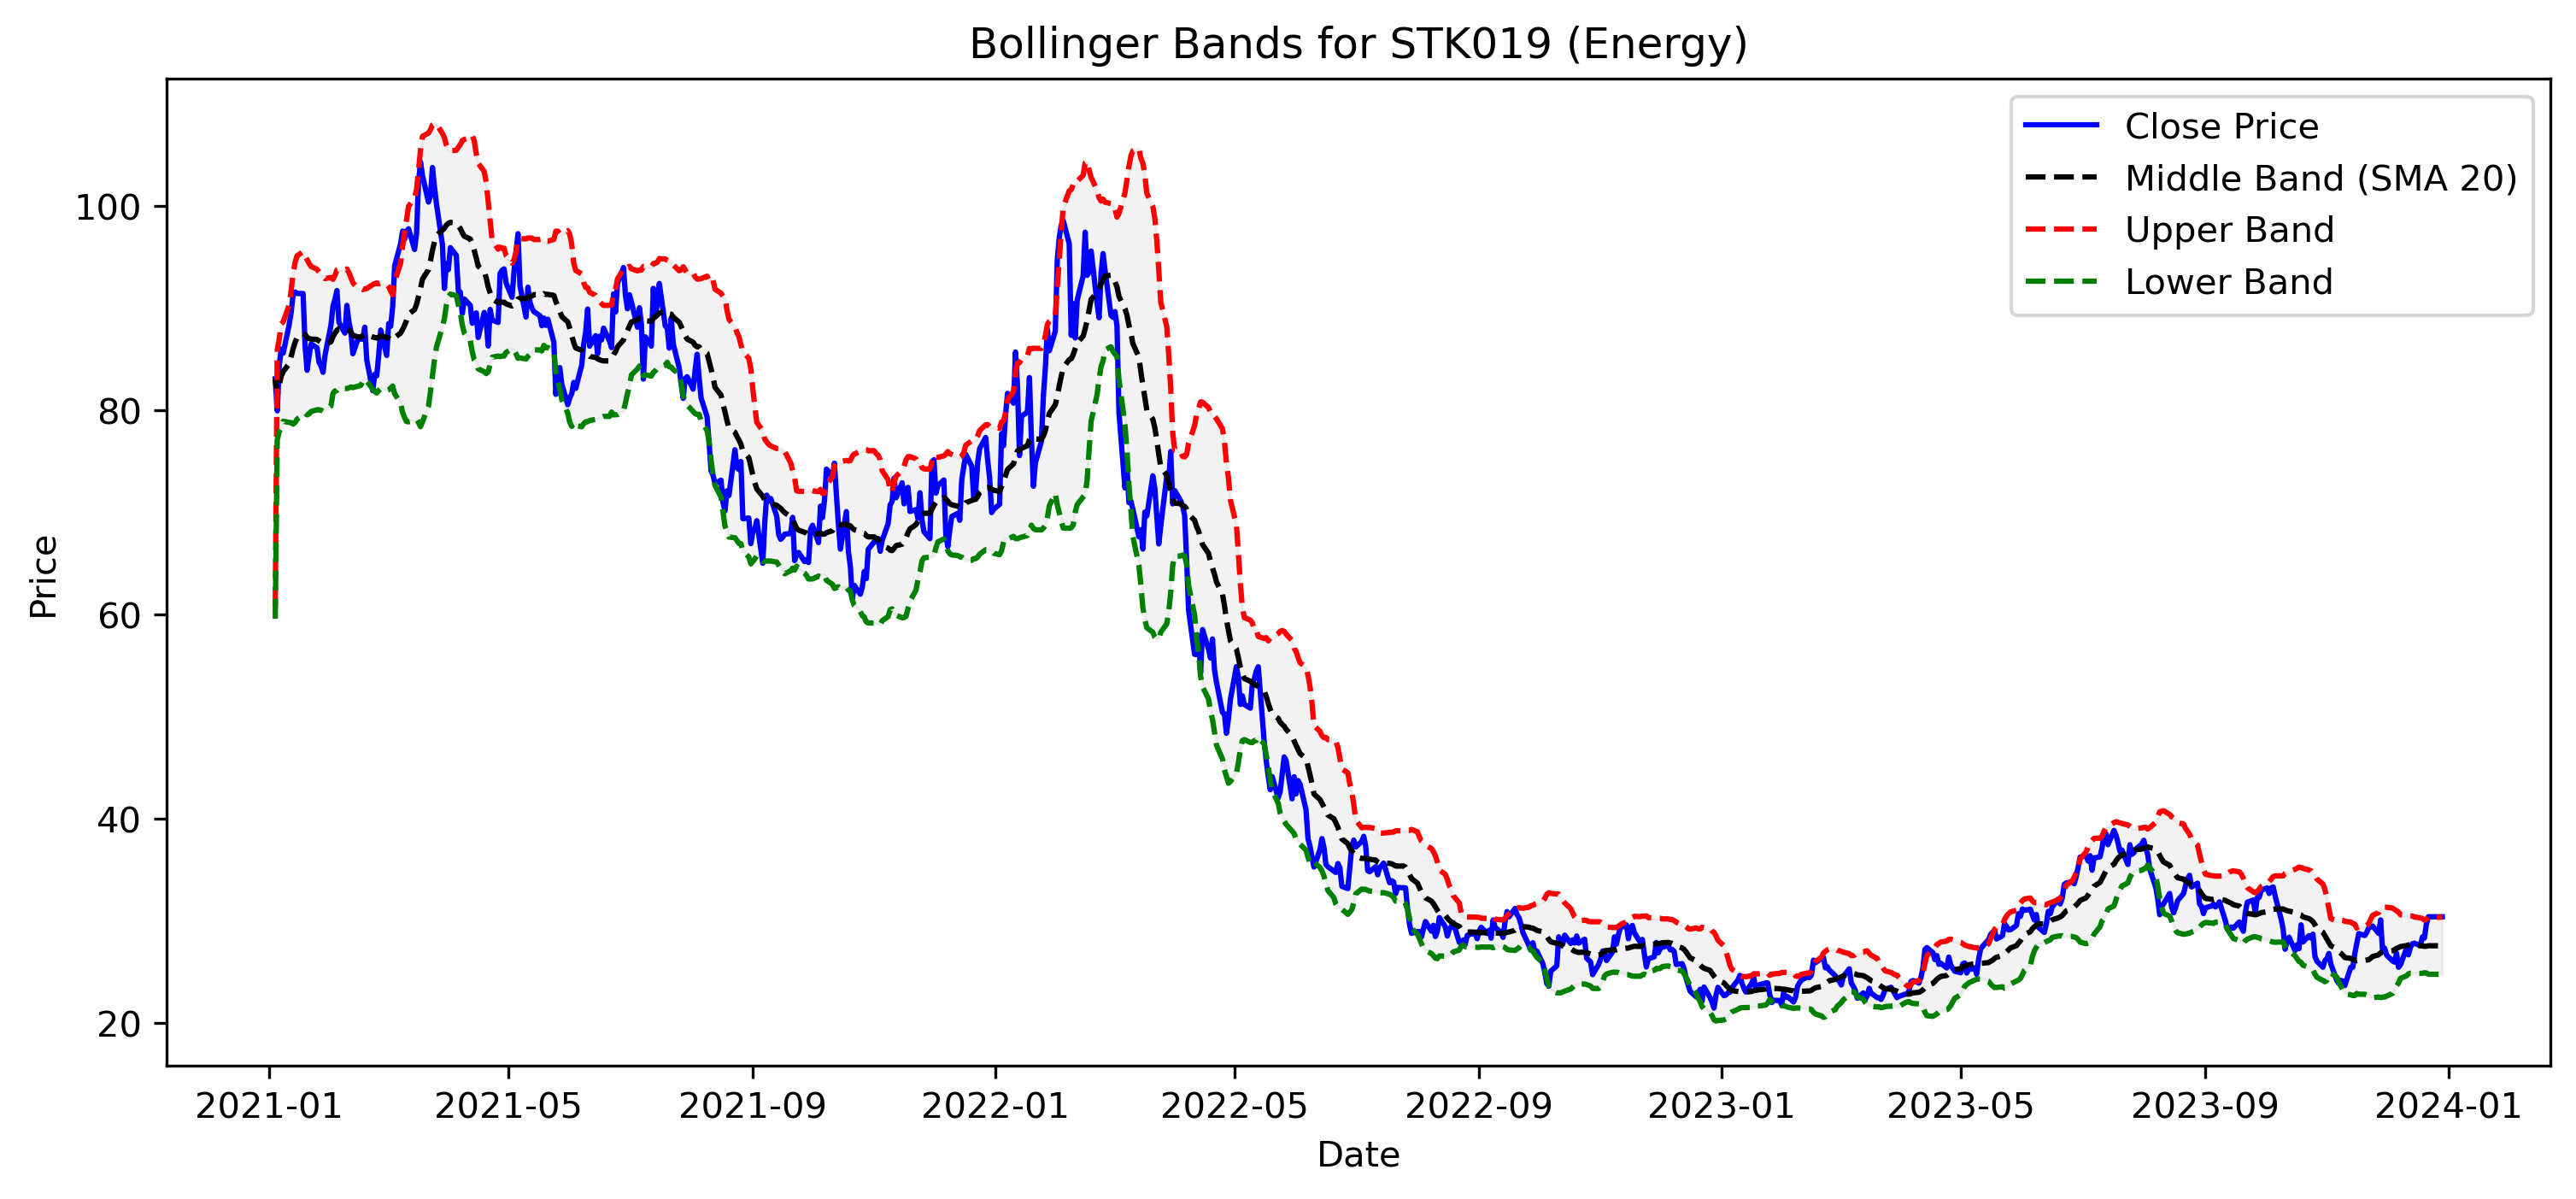

In [14]:
display(Image('../visuals/eda/bollinger_band_selected_ticker.png'))

### 5. Correlation Heatmap

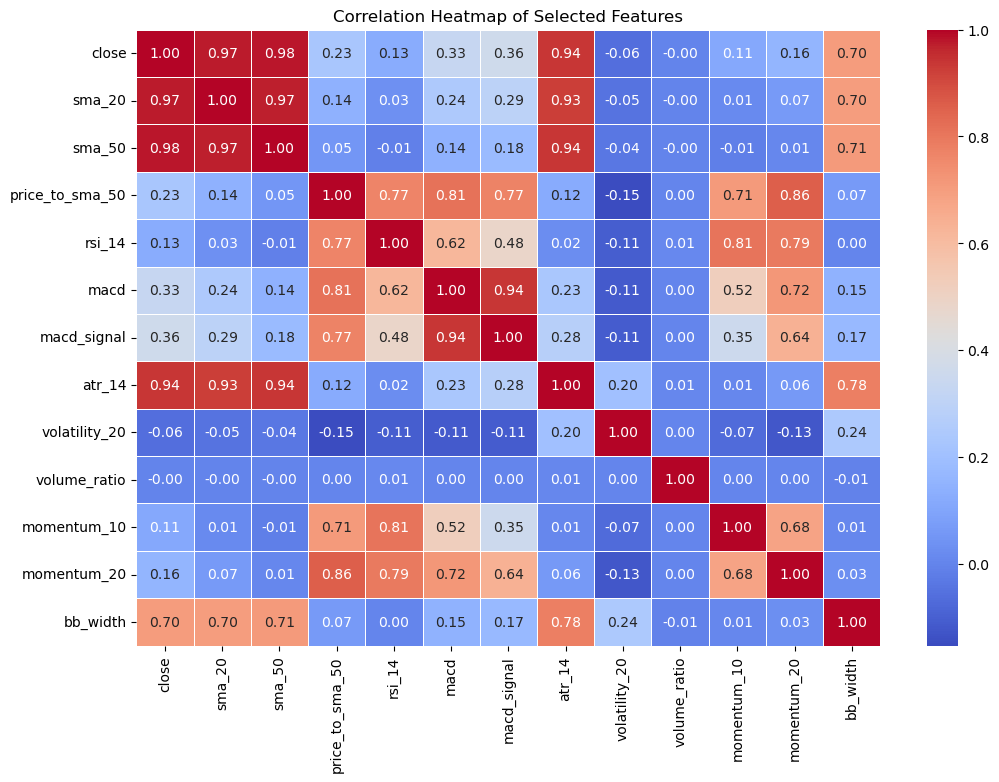

In [15]:
display(Image('../visuals/eda/correlation_heatmap.png'))

### Insignt from the EDA (using the correlation heatmap)
Price and Moving Averages:
close, sma_20, and sma_50 are very highly correlated (>0.97), indicating they move together closely.
price_to_sma_50 has moderate correlation with rsi_14 (0.76) and macd (0.83), reflecting its relation to momentum indicators.

Momentum Indicators:
rsi_14 and momentum_10/20 show strong positive correlation (~0.80), confirming they capture similar price strength signals.
macd and macd_signal are extremely correlated (0.96), as expected from the MACD calculation.

Volatility Measures:
atr_14 correlates strongly with bb_width (0.80) and with price/MAs (~0.94), indicating that volatility increases with price movement magnitude.
volatility_20 has low correlations with most features except bb_width (0.24), showing it measures a slightly different aspect of price variability.

Volume and Returns:
volume_ratio shows nearly zero correlation with other features, suggesting volume-based signals are largely independent.

Bollinger Bands
bb_width is strongly correlated with atr_14 and moderately with close/MA features (~0.72), reflecting how bands widen during high volatility.


## C. Modeling Summary

###   Baseline Model

Model: Logistic Regression

Accuracy: ~36%

Confusion matrix shows strong bias toward predicting the dominant class.

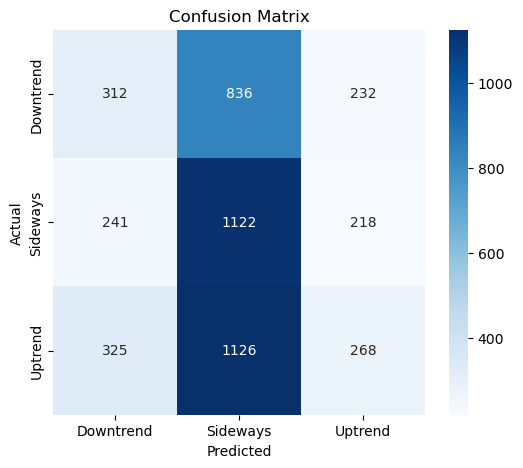

In [16]:
display(Image('../visuals/model_performance/confusion_matric_logreg.png'))

### Random Forest Model

Accuracy: ~35%

Improved class separation compared to the baseline.

Better ability to capture non-linear relationships.

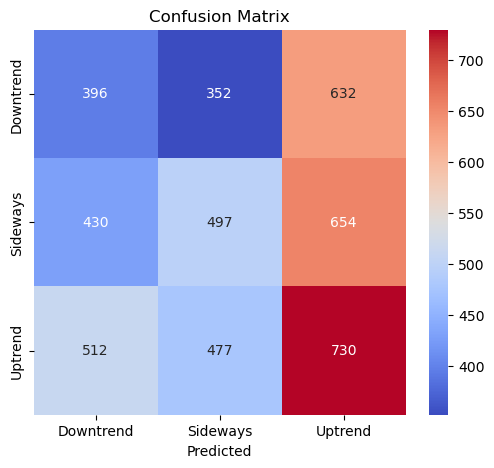

In [18]:
display(Image('../visuals/model_performance/confusion_matrix_rf.png'))

### Tuned Random Forest Model
Accuracy: ~37%


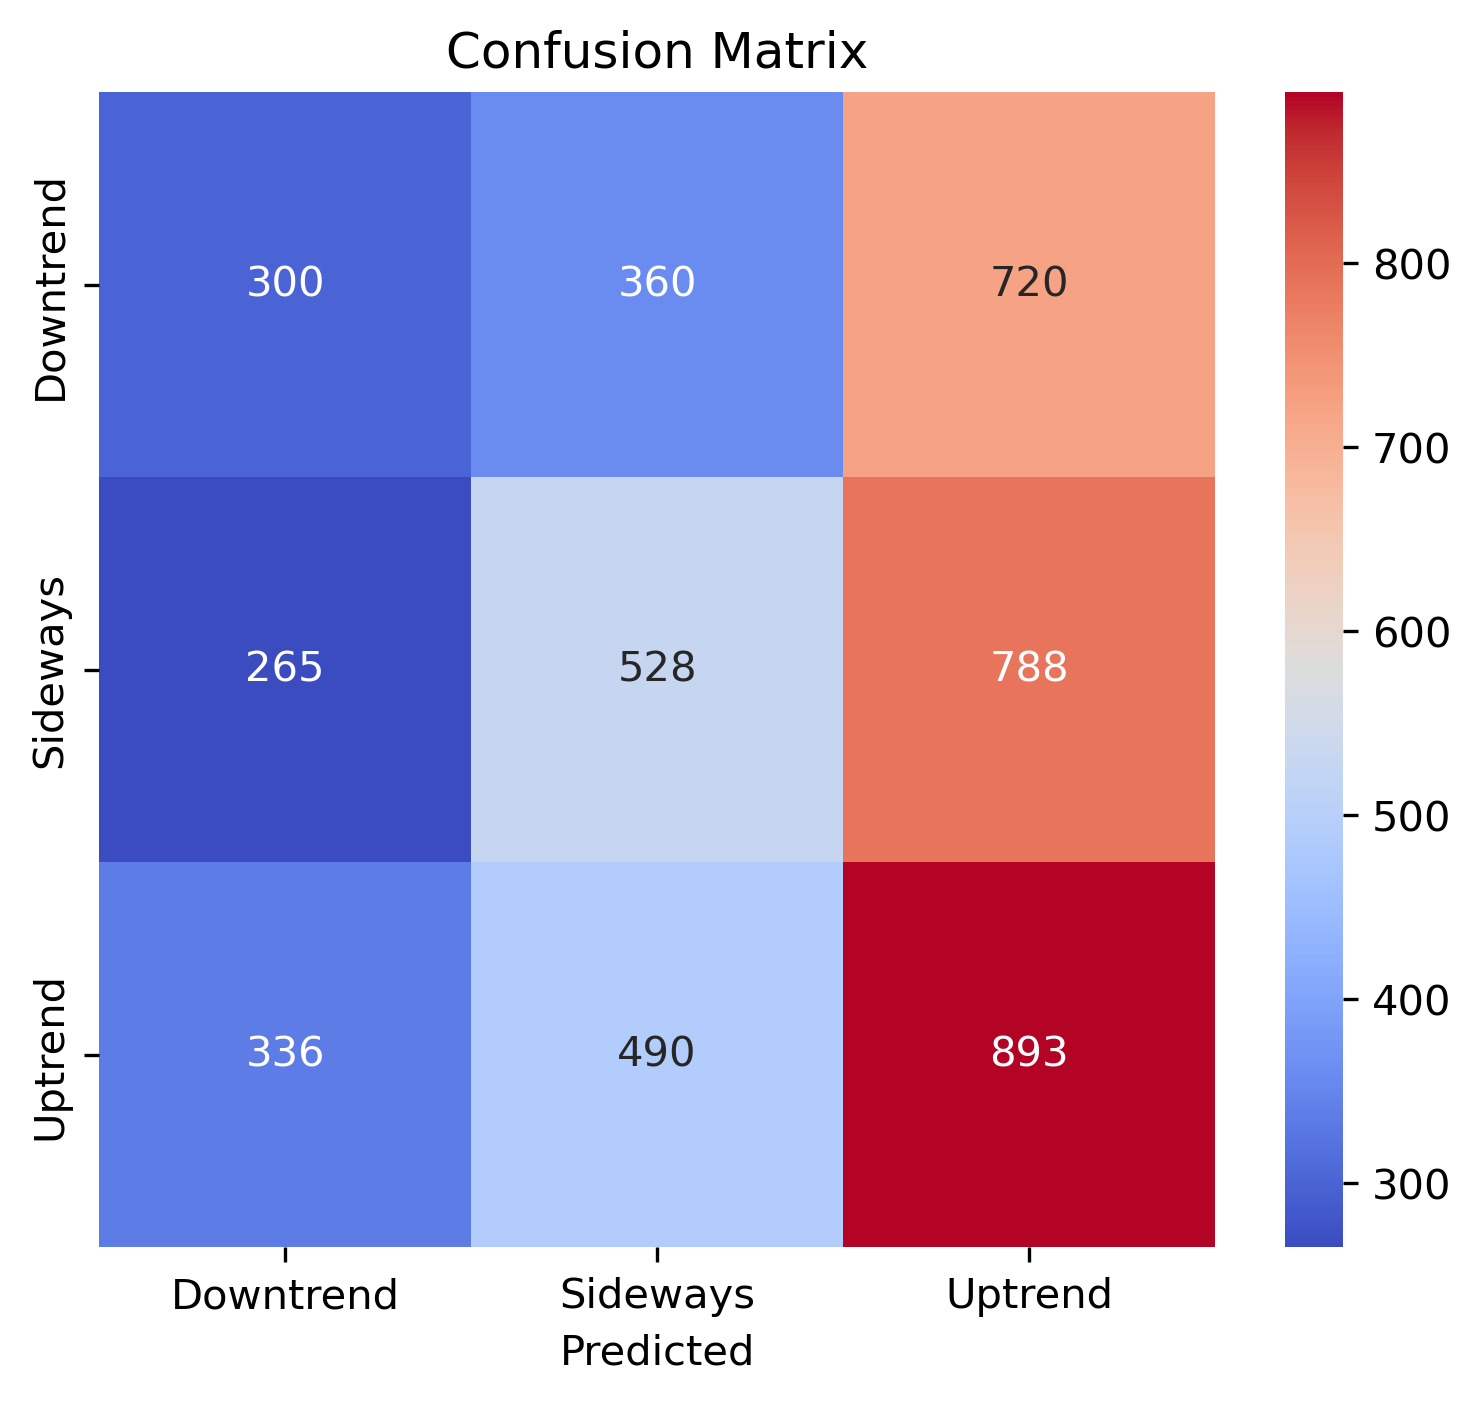

In [19]:
display(Image('../visuals/model_performance/confusion_matrix_rf_tuned.png'))

### Model Comparison

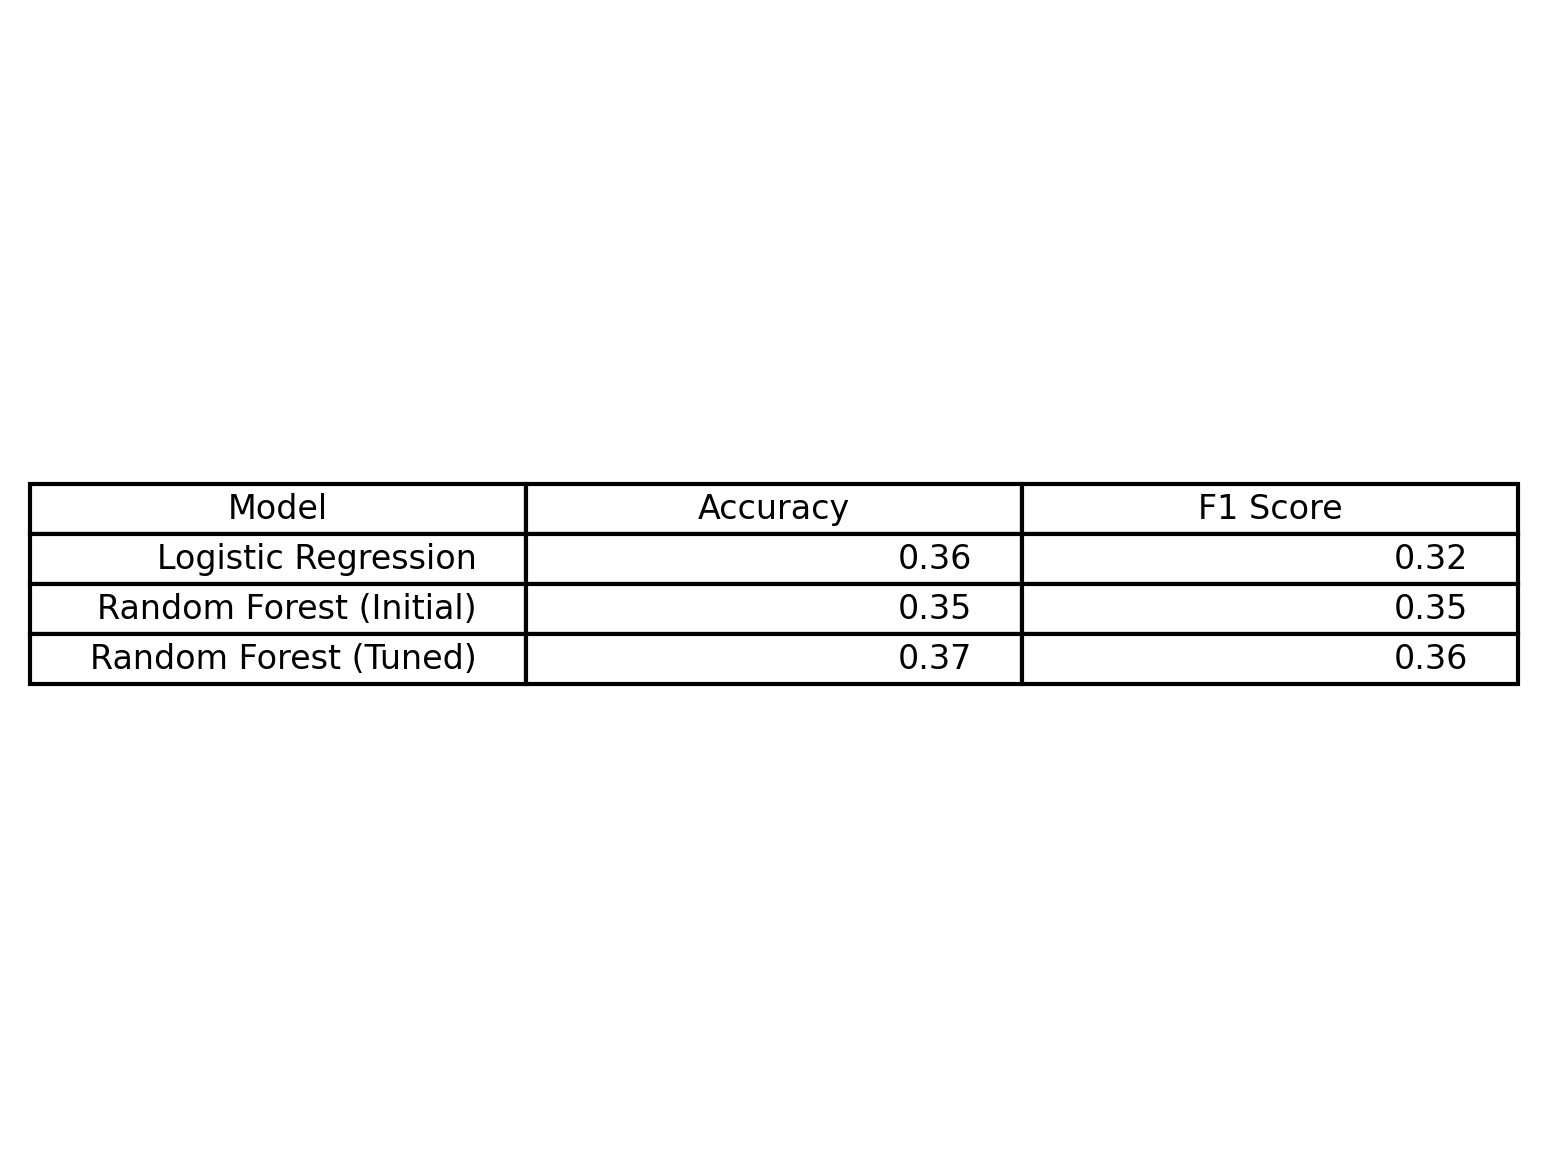

In [25]:
display(Image('../visuals/summary/comparison_table.png'))

### Key insights:
#### ogistic Regression (Baseline)
Serves as a strong baseline for a noisy financial prediction task.
Accuracy is reasonable, but the lower F1 score (0.32) indicates poor balance between precision and recall across classes.

#### Random Forest (Initial)
Accuracy slightly drops, but F1 score improves significantly (0.35).
This shows the model handles class imbalance and non-linear relationships better than Logistic Regression.

#### Random Forest (Tuned)
Achieves the best overall performance.
Improvements in both accuracy (0.37) and F1 score (0.36) indicate better generalization and more balanced predictions.
The gain is modest, which is expected in financial markets due to high noise and indicator lag.

#### Conclusion:
The tuned Random Forest provides the best trade-off between accuracy and class balance, confirming that model tuning and non-linear methods add value, even if gains remain incremental.

## D. Feature Importance

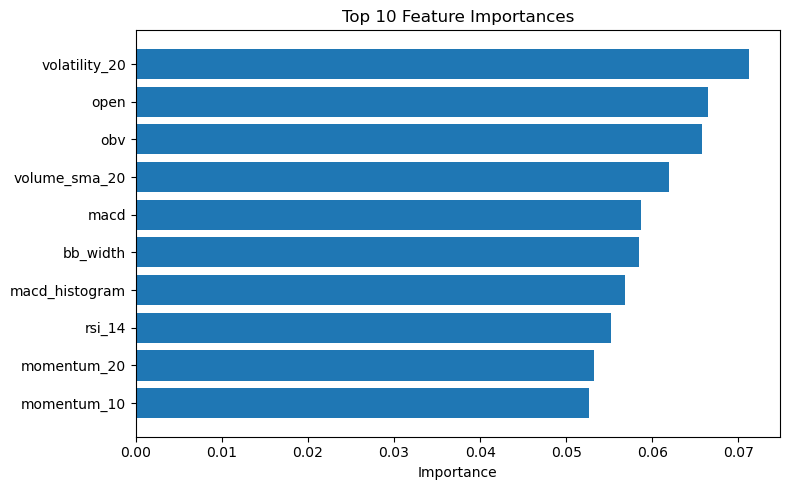

In [24]:
display(Image('../visuals/model_performance/feature_importance_rf.png'))

#### The top contributing features include:

Volatility (20-day)
Open price
On-Balance Volume (OBV)
Volume moving average
MACD and MACD histogram
RSI
Bollinger Band width
Momentum and lagged returns

These features show that momentum, volatility, and volume-based indicators play a larger role than raw prices alone.
This aligns with trading intuition, as trend strength and confirmation signals are critical for market direction.

## E. Final Insights & Recommendations

Financial markets are highly noisy, so modest accuracy is expected.
Technical indicators lag price movements, making turning points difficult to predict.
The tuned Random Forest model performs better than the baseline by capturing non-linear patterns.

#### Next steps include:

Backtesting trading strategies

Applying rolling-window validation and MLOps practices